# Taller 5
**Autores:** Sumin Han, Juan David Nieto

## Cargamos la base de datos cancer.csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/oscar-bustos/javeriana-analitica/refs/heads/main/taller3/cancer.csv')
print(f'Shape: {df.shape}')
print(f'\nColumnas: {list(df.columns)}')
print(f'\nDistribución Diagnosis:\n{df["Diagnosis"].value_counts()}')
df.head()

Shape: (569, 31)

Columnas: ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3', 'Diagnosis']

Distribución Diagnosis:
Diagnosis
B    357
M    212
Name: count, dtype: int64


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Hacemos limpieza de datos eliminando los valores nulos

In [ ]:

nulos_por_columna = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos_por_columna[nulos_por_columna > 0] if nulos_por_columna.sum() > 0 else "No hay valores nulos")
print(f"\nTotal valores nulos: {df.isnull().sum().sum()}")
print(f"Shape antes de limpieza: {df.shape}")

df = df.dropna()

print(f"después de limpieza: {df.shape}")



Valores nulos por columna:
No hay valores nulos

Total valores nulos: 0
Shape antes de limpieza: (569, 31)
después de limpieza: (569, 31)


## Nos damos cuenta de que no hay datos nulos

### Dividimos los datos en 80% train y 20% test

In [ ]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print(f"\nDistribución en entrenamiento:\n{y_train.value_counts()}")
print(f"\nDistribución en prueba:\n{y_test.value_counts()}")

X_train: (455, 30)  |  X_test: (114, 30)
y_train: (455,)  |  y_test: (114,)

Distribución en entrenamiento:
Diagnosis
B    285
M    170
Name: count, dtype: int64

Distribución en prueba:
Diagnosis
B    72
M    42
Name: count, dtype: int64


## Entrenamiento de ensambles clasficadores

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#  Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
print("RandomForestClassifier")

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train_scaled, y_train)
print("b. GradientBoostingClassifier ")

#  Voting Classifier
estimadores = [
    ('lr',       Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))])),
    ('svc_lin',  Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='linear',  probability=True, random_state=42))])),
    ('svc_poly', Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='poly',    probability=True, random_state=42))])),
    ('svc_rbf',  Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf',     probability=True, random_state=42))])),
    ('dt',       DecisionTreeClassifier(random_state=42)),
]

voting = VotingClassifier(estimators=estimadores, voting='soft')
voting.fit(X_train_scaled, y_train)
print("c. VotingClassifier")
print("   i.   LogisticRegression")
print("   ii.  SVC kernel lineal")
print("   iii. SVC kernel polinómico")
print("   iv.  SVC kernel radial")
print("   v.   DecisionTreeClassifier")

from sklearn.ensemble import StackingClassifier

#  Stacking Classifier
base_learners = [
    ('dt',       DecisionTreeClassifier(random_state=42)),
    ('svc_lin',  Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='linear',  probability=True, random_state=42))])),
    ('svc_poly', Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='poly',    probability=True, random_state=42))])),
    ('svc_rbf',  Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf',     probability=True, random_state=42))])),
]

stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)
stacking.fit(X_train_scaled, y_train)
print("d. StackingClassifier")
print("    DecisionTreeClassifier")
print("    SVC kernel lineal")
print("    SVC kernel polinómico")
print("    SVC kernel radial")
print("   final_estimator: LogisticRegression")


RandomForestClassifier
b. GradientBoostingClassifier 
c. VotingClassifier
   i.   LogisticRegression
   ii.  SVC kernel lineal
   iii. SVC kernel polinómico
   iv.  SVC kernel radial
   v.   DecisionTreeClassifier
d. StackingClassifier
    DecisionTreeClassifier
    SVC kernel lineal
    SVC kernel polinómico
    SVC kernel radial
   final_estimator: LogisticRegression


# Tabla comparativa de emambles

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

modelos = {
    'Random Forest':       rf,
    'Gradient Boosting':   gb,
    'Voting Classifier':   voting,
    'Stacking Classifier': stacking,
}

filas = []
for nombre, modelo in modelos.items():
    y_train_pred = modelo.predict(X_train_scaled)
    y_test_pred  = modelo.predict(X_test_scaled)
    filas.append({
        'Modelo':              nombre,
        'Accuracy Train':      accuracy_score(y_train, y_train_pred),
        'Accuracy Test':       accuracy_score(y_test,  y_test_pred),
        'F1 Train':            f1_score(y_train, y_train_pred, pos_label='M'),
        'F1 Test':             f1_score(y_test,  y_test_pred,  pos_label='M'),
    })

tabla = pd.DataFrame(filas).set_index('Modelo')
tabla = tabla.applymap(lambda x: f"{x:.4f}")
tabla

/tmp/ipython-input-174/604653721.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tabla = tabla.applymap(lambda x: f"{x:.4f}")


,Accuracy Train,Accuracy Test,F1 Train,F1 Test
Modelo,,,,
Random Forest,1.0000,0.9649,1.0000,0.9500
Gradient Boosting,1.0000,0.9649,1.0000,0.9500
Voting Classifier,0.9934,0.9825,0.9911,0.9756
Stacking Classifier,0.9912,0.9825,0.9881,0.9756


# Conclusiones

### Tenemos sobreajuste en Random forest, Gradient boosting, voting classifier, stacking classifier, memorizan el entrenamiento por "Accuracy Train=1.0" Esto sucede debido a que nuestro data set contiene informacion de unicamente de pacientes diagnosticados con cancer y por eso el modelo se aprende los datos.



# Ejercicio 2


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/oscar-bustos/javeriana-analitica/refs/heads/main/housing/housing.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/oscar-bustos/javeriana-analitica/refs/heads/main/housing/train.csv')
display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [ ]:
df2.shape

(1460, 81)

###Verificar el porcentaje de nulos para cada variable

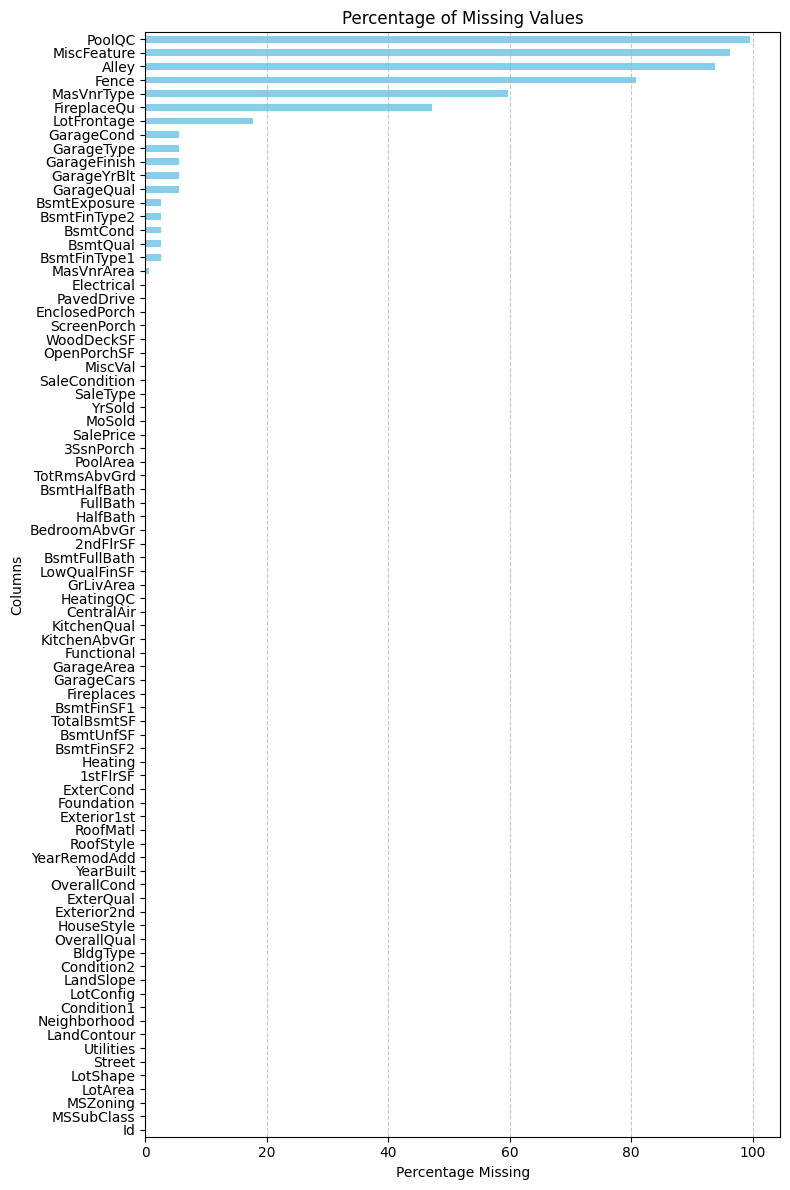

In [ ]:
import matplotlib.pyplot as plt

null_pct = df2.isnull().mean() * 100

colors = ['red' if x == 100 else 'skyblue' for x in null_pct]

plt.figure(figsize=(8, 12))
null_pct.sort_values().plot(kind='barh', color=colors)

plt.title('Percentage of Missing Values')
plt.xlabel('Percentage Missing')
plt.ylabel('Columns')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add a text label for the 100% bars if there are not too many
for i, v in enumerate(null_pct.sort_values()):
    if v == 100:
        plt.text(v, i, f' {v:.0f}%', va='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
cols_with_nulls_index = df2.columns[df2.isnull().any()]

# Convert the Index to a Python list
cols_with_nulls_list = cols_with_nulls_index.tolist()

df_nulls = df2[cols_with_nulls_list]
df_nulls.head()

,LotFrontage,Alley,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
0,65.0,NaN,BrkFace,196.0,Gd,TA,No,GLQ,Unf,SBrkr,NaN,Attchd,2003.0,RFn,TA,TA,NaN,NaN,NaN
1,80.0,NaN,NaN,0.0,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,1976.0,RFn,TA,TA,NaN,NaN,NaN
2,68.0,NaN,BrkFace,162.0,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,2001.0,RFn,TA,TA,NaN,NaN,NaN
3,60.0,NaN,NaN,0.0,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,1998.0,Unf,TA,TA,NaN,NaN,NaN
4,84.0,NaN,BrkFace,350.0,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,2000.0,RFn,TA,TA,NaN,NaN,NaN


In [ ]:
null_percentage=df_nulls.isnull().mean()*100
null_percentage.sort_values(ascending=False)

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


###Primero se eliminara las columnas con valores nulos con más del 50%

In [ ]:
df_clean = df2.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'])

In [ ]:
# Eliminar filas con valores nulos
df_clean = df_clean.dropna()


print("Base de Datos original:", df2.shape)
print("Base de Datos impio de nulos:", df_clean.shape)

display(df_clean.head())

# verificar los tipos de datos y valores no nulos
df_clean.info()

Base de Datos original: (1460, 81)
Base de Datos impio de nulos: (1094, 75)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1094 non-null   int64  
 1   MSSubClass     1094 non-null   int64  
 2   MSZoning       1094 non-null   object 
 3   LotFrontage    1094 non-null   float64
 4   LotArea        1094 non-null   int64  
 5   Street         1094 non-null   object 
 6   LotShape       1094 non-null   object 
 7   LandContour    1094 non-null   object 
 8   Utilities      1094 non-null   object 
 9   LotConfig      1094 non-null   object 
 10  LandSlope      1094 non-null   object 
 11  Neighborhood   1094 non-null   object 
 12  Condition1     1094 non-null   object 
 13  Condition2     1094 non-null   object 
 14  BldgType       1094 non-null   object 
 15  HouseStyle     1094 non-null   object 
 16  OverallQual    1094 non-null   int64  
 17  OverallCond    1094 non-null   int64  
 18  YearBuilt    

In [ ]:
#Confirmar que no hay ningún valor nulo en el nuevo dataframe
hay_nulo = df_clean.isnull().any().any()
print(hay_nulo)

False


In [ ]:
df_new = df_clean.drop(columns=['SalePrice', 'Id'])
X = df_new
y = df_clean['SalePrice']

In [ ]:
#Separar el dataframe entre train y test (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Profe, según la información del dataset en Kaggle este es un conjunto de datos para una problema de Regresión y no de clasificación asi que nos parece raro utilizar Random Forest Classifier y Gradient Boosting Classifier. Además el link del conjunto de datos del github no contiene la variable de enfoque "SalesPrice" y por eso utilizamos el otro conjuto de datos "train.csv" que está en el github

###Modelo Random Forest (Clasificación)

In [ ]:
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding to training and test sets
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial if some categories are in train but not test, or vice versa
# This ensures both dataframes have the same columns in the same order
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

rf = RandomForestClassifier(n_estimators=100 , max_depth=5, random_state=42)
rf.fit(X_train_encoded, Y_train)

y_train_pred = rf.predict(X_train_encoded)
y_test_pred = rf.predict(X_test_encoded)

mse_train = mean_squared_error(Y_train, y_train_pred)
mae_train = mean_absolute_error(Y_train, y_train_pred)
r2_train = r2_score(Y_train, y_train_pred)

mse_test = mean_squared_error(Y_test, y_test_pred)
mae_test = mean_absolute_error(Y_test, y_test_pred)
r2_test = r2_score(Y_test, y_test_pred)

print(f"Training Mean Squared Error: {mse_train:.2f}")
print(f"Training Mean Absolute Error: {mae_train:.2f}")
print(f"Training R-squared: {r2_train:.2f}")
print(f"\nTest Mean Squared Error: {mse_test:.2f}")
print(f"Test Mean Absolute Error: {mae_test:.2f}")
print(f"Test R-squared: {r2_test:.2f}")

Training Mean Squared Error: 1123401196.19
Training Mean Absolute Error: 16068.91
Training R-squared: 0.83

Test Mean Squared Error: 4733177653.36
Test Mean Absolute Error: 44325.31
Test R-squared: 0.37


###Melo Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import pandas as pd # Added pandas import for X_train_encoded etc.

# Initialize and train the Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train_encoded, Y_train)

# Make predictions on training and test data
y_train_pred_gb = gb.predict(X_train_encoded)
y_test_pred_gb = gb.predict(X_test_encoded)

# Calculate metrics for training data (these metrics are typically for regression, and may not be meaningful for classification output)
mse_train_gb = mean_squared_error(Y_train, y_train_pred_gb)
mae_train_gb = mean_absolute_error(Y_train, y_train_pred_gb)
r2_train_gb = r2_score(Y_train, y_train_pred_gb)

# Calculate metrics for test data
mse_test_gb = mean_squared_error(Y_test, y_test_pred_gb)
mae_test_gb = mean_absolute_error(Y_test, y_test_pred_gb)
r2_test_gb = r2_score(Y_test, y_test_pred_gb)

print(f"Gradient Boosting Classifier - Training Metrics:")
print(f"  Mean Squared Error: {mse_train_gb:.2f}")
print(f"  Mean Absolute Error: {mae_train_gb:.2f}")
print(f"  R-squared: {r2_train_gb:.2f}")

print(f"\nGradient Boosting Classifier - Test Metrics:")
print(f"  Mean Squared Error: {mse_test_gb:.2f}")
print(f"  Mean Absolute Error: {mae_test_gb:.2f}")
print(f"  R-squared: {r2_test_gb:.2f}")

Gradient Boosting Classifier - Training Metrics:
  Mean Squared Error: 7918468.57
  Mean Absolute Error: 103.31
  R-squared: 1.00

Gradient Boosting Classifier - Test Metrics:
  Mean Squared Error: 6716180454.24
  Mean Absolute Error: 47624.68
  R-squared: 0.11


###Modelo LightGBM

In [ ]:
!pip install lightgbm

from lightgbm import LGBMRegressor

# Initialize and train the LightGBM Regressor
lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train_encoded, Y_train)

# Make predictions on training and test data
y_train_pred_lgbm = lgbm.predict(X_train_encoded)
y_test_pred_lgbm = lgbm.predict(X_test_encoded)

# Calculate metrics for training data
mse_train_lgbm = mean_squared_error(Y_train, y_train_pred_lgbm)
mae_train_lgbm = mean_absolute_error(Y_train, y_train_pred_lgbm)
r2_train_lgbm = r2_score(Y_train, y_train_pred_lgbm)

# Calculate metrics for test data
mse_test_lgbm = mean_squared_error(Y_test, y_test_pred_lgbm)
mae_test_lgbm = mean_absolute_error(Y_test, y_test_pred_lgbm)
r2_test_lgbm = r2_score(Y_test, y_test_pred_lgbm)

print(f"LightGBM Regressor - Training Metrics:")
print(f"  Mean Squared Error: {mse_train_lgbm:.2f}")
print(f"  Mean Absolute Error: {mae_train_lgbm:.2f}")
print(f"  R-squared: {r2_train_lgbm:.2f}")

print(f"\nLightGBM Regressor - Test Metrics:")
print(f"  Mean Squared Error: {mse_test_lgbm:.2f}")
print(f"  Mean Absolute Error: {mae_test_lgbm:.2f}")
print(f"  R-squared: {r2_test_lgbm:.2f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003086 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2831
[LightGBM] [Info] Number of data points in the train set: 875, number of used features: 129
[LightGBM] [Info] Start training from score 186832.529143
LightGBM Regressor - Training Metrics:
  Mean Squared Error: 158276755.17
  Mean Absolute Error: 5252.75
  R-squared: 0.98

LightGBM Regressor - Test Metrics:
  Mean Squared Error: 745313614.64
  Mean Absolute Error: 17232.79
  R-squared: 0.90


###Modelo XGBoost

In [ ]:
!pip install xgboost

from xgboost import XGBRegressor

# Initialize and train the XGBoost Regressor
xgboost = XGBRegressor(random_state=42)
xgboost.fit(X_train_encoded, Y_train)

# Make predictions on training and test data
y_train_pred_xgb = xgboost.predict(X_train_encoded)
y_test_pred_xgb = xgboost.predict(X_test_encoded)

# Calculate metrics for training data
mse_train_xgb = mean_squared_error(Y_train, y_train_pred_xgb)
mae_train_xgb = mean_absolute_error(Y_train, y_train_pred_xgb)
r2_train_xgb = r2_score(Y_train, y_train_pred_xgb)

# Calculate metrics for test data
mse_test_xgb = mean_squared_error(Y_test, y_test_pred_xgb)
mae_test_xgb = mean_absolute_error(Y_test, y_test_pred_xgb)
r2_test_xgb = r2_score(Y_test, y_test_pred_xgb)

print(f"XGBoost Regressor - Training Metrics:")
print(f"  Mean Squared Error: {mse_train_xgb:.2f}")
print(f"  Mean Absolute Error: {mae_train_xgb:.2f}")
print(f"  R-squared: {r2_train_xgb:.2f}")

print(f"\nXGBoost Regressor - Test Metrics:")
print(f"  Mean Squared Error: {mse_test_xgb:.2f}")
print(f"  Mean Absolute Error: {mae_test_xgb:.2f}")
print(f"  R-squared: {r2_test_xgb:.2f}")

XGBoost Regressor - Training Metrics:
  Mean Squared Error: 507974.00
  Mean Absolute Error: 468.70
  R-squared: 1.00

XGBoost Regressor - Test Metrics:
  Mean Squared Error: 834679744.00
  Mean Absolute Error: 18571.55
  R-squared: 0.89


##Mejor modelo: LightGBM

##Interfaz Gráfica Gradio

In [ ]:
pip install gradio==4.36.1 huggingface_hub==0.19.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.7/311.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.1/318.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.8 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
  Attempting uninstall: tomlkit
    Found existing installation: tomlkit 0.13.3
    Uninstalling tomlkit-0.13.3:
      Successfully uninstalled tomlkit-0.13.3
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.3
    Uninstalling MarkupSafe-3.0.

In [ ]:
import gradio as gr
import pandas as pd

# 1. PREPARATION: Filter out the target and any non-predictive IDs
# Change 'SalePrice' and 'Id' if your column names are different
target_col = 'SalePrice'
drop_cols = ['SalePrice', 'Id', 'PID']
features_only = [col for col in df_clean.columns if col not in drop_cols]

cat_cols = [col for col in features_only if df[col].dtype == 'object']

import traceback

from sklearn.preprocessing import LabelEncoder

def predict_price(*args):
    # 1. Create a dataframe from inputs
    user_input_df = pd.DataFrame([args], columns=features_only)

    # 2. TRANSFORM: Use the exact same encoding method used for X_train_encoded
    # If you used pd.get_dummies(df), you MUST use it here:
    user_input_df_encoded = pd.get_dummies(user_input_df)

    # 3. ALIGN: Ensure the columns match exactly
    # We reindex to ensure that if a column is missing (because a category
    # wasn't selected), it gets filled with 0.
    user_input_df_encoded = user_input_df_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

    # 4. Predict
    prediction = lgbm.predict(user_input_df_encoded)
    return f"${prediction[0]:,.2f}"

# 2. INTERFACE: Build the UI dynamically
with gr.Blocks(title="Ames Housing Predictor") as demo:
    gr.Markdown("# Ames Housing Price Predictor")
    gr.Markdown("Adjust the property features below to estimate the sale price.")

    # Accordion to organize the 80 inputs
    with gr.Accordion("Property Features (Click to adjust)", open=True):
        input_components = []

        # Loop through features to build components
        for col in features_only:
            # If category, create a dropdown
            if df_clean[col].dtype == 'object' or df_clean[col].dtype.name == 'category':
                choices = sorted([str(x) for x in df_clean[col].dropna().unique()])
                # Default to the first choice if available
                comp = gr.Dropdown(choices=choices, label=col, value=choices[0] if choices else None)
            # If numeric, create a number input
            else:
                comp = gr.Number(label=col, value=float(df_clean[col].mean()))

            input_components.append(comp)

    # 3. OUTPUT
    btn = gr.Button("Calculate Price", variant="primary")
    output = gr.Textbox(label="Estimated Sale Price")

    # 4. ACTION
    btn.click(fn=predict_price, inputs=input_components, outputs=output)

# Launch the app
demo.launch()

IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------
Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://0473a75349657a647d.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
